# Project - Time Series Forecasting in Finance

## Daily Forecasting of the CAC 40 Index (`^FCHI`)

### Dataset choice

For this project, I chose a **single univariate financial time series** : the daily closing level of the CAC 40 index. I also find it interesting from a finance point of view : a broad equity index reflects the overall market, reacts to major shocks, and gives a good basis for discussing trend, volatility and predictability.

### Objective

The notebook follows these steps :

1. data preparation, exploratory analysis and decomposition
2. a baseline and a statistical time-series model
3. classical machine learning with three model families
4. deep learning with an LSTM and a final model comparison

## Libraries and reproducibility

The notebook uses standard Python libraries for data analysis, time-series modelling, machine learning and deep learning. To make the workflow easier to reproduce, a local CSV file is reused once the dataset has been downloaded.

In [ ]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
pd.set_option("display.max_columns", 100)
tf.keras.utils.set_random_seed(42)
tf.get_logger().setLevel("ERROR")

In [ ]:
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SYMBOL = "^FCHI"
START_DATE = "2010-01-01"
END_DATE = "2026-01-01"
TEST_SIZE = 0.20
LSTM_WINDOW = 21

DATA_CACHE_PATH = DATA_DIR / "cac40_daily.csv"

## 1. Data acquisition and initial preparation

The series is retrieved from `yfinance`. If a local CSV file is already available, it is loaded first in order to keep the results reproducible and avoid downloading the same data again.

The retained market variables are:

- `Open`
- `High`
- `Low`
- `Close`
- `Volume`

The forecasting target is the **closing level of the CAC 40**.

In [ ]:
if DATA_CACHE_PATH.exists():
    df = pd.read_csv(DATA_CACHE_PATH, parse_dates=["date"], index_col="date")
    df.columns.name = None
    data_source = "local CSV cache"
else:
    raw = yf.download(
        SYMBOL,
        start=START_DATE,
        end=END_DATE,
        interval="1d",
        auto_adjust=True,
        progress=False,
    )

    if raw.empty:
        raise ValueError("The download returned an empty DataFrame. The ticker or the network connection should be checked.")

    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    raw.columns.name = None

    df = (
        raw.rename(columns=str.lower)
        .rename_axis("date")
        .sort_index()
        .copy()
    )

    df = df[["open", "high", "low", "close", "volume"]]
    df = df[~df.index.duplicated(keep="last")].dropna(subset=["close"]).copy()

    df["return_1d"] = df["close"].pct_change()
    df["log_close"] = np.log(df["close"])
    df["volatility_21"] = df["return_1d"].rolling(21).std() * np.sqrt(252)

    df.to_csv(DATA_CACHE_PATH)
    data_source = "yfinance download"

if "return_1d" not in df.columns:
    df["return_1d"] = df["close"].pct_change()
if "log_close" not in df.columns:
    df["log_close"] = np.log(df["close"])
if "volatility_21" not in df.columns:
    df["volatility_21"] = df["return_1d"].rolling(21).std() * np.sqrt(252)

df.columns.name = None

print(f"Data source: {data_source}")
print(f"Period covered: {df.index.min().date()} to {df.index.max().date()}")
print(f"Number of observations: {len(df)}")

df.head()

Data source: local CSV cache
Period covered: 2010-01-04 to 2025-12-31
Number of observations: 4091


,open,high,low,close,volume,return_1d,log_close,volatility_21
date,,,,,,,,
2010-01-04,3952.209961,4013.969971,3950.610107,4013.969971,113396000,NaN,8.297536,NaN
2010-01-05,4012.429932,4028.340088,3993.330078,4012.909912,129518600,-0.000264,8.297272,NaN
2010-01-06,4014.449951,4022.939941,3996.800049,4017.669922,110087000,0.001186,8.298457,NaN
2010-01-07,4005.959961,4032.239990,3983.899902,4024.800049,118430400,0.001775,8.300231,NaN
2010-01-08,4042.639893,4051.409912,4013.340088,4045.139893,131783200,0.005054,8.305271,NaN


In [ ]:
print("Missing values by column:")
display(df.isna().sum())

display(df.describe().T.round(3))

Missing values by column:


open              0
high              0
low               0
close             0
volume            0
return_1d         1
log_close         0
volatility_21    21
dtype: int64

,count,mean,std,min,25%,50%,75%,max
open,4091.0,5.303603e+03,1.431198e+03,2754.820,4.173795e+03,5.070670e+03,6.507410e+03,8.270850e+03
high,4091.0,5.335886e+03,1.434518e+03,2823.970,4.202530e+03,5.101220e+03,6.542190e+03,8.314230e+03
low,4091.0,5.268849e+03,1.428721e+03,2693.210,4.130395e+03,5.039190e+03,6.453285e+03,8.227880e+03
close,4091.0,5.303264e+03,1.431485e+03,2781.680,4.162790e+03,5.071100e+03,6.498425e+03,8.258860e+03
volume,4091.0,9.926726e+07,4.829216e+07,0.000,6.777790e+07,8.878180e+07,1.229701e+08,4.385013e+08
return_1d,4090.0,0.000000e+00,1.200000e-02,-0.123,-5.000000e-03,1.000000e-03,6.000000e-03,9.700000e-02
log_close,4091.0,8.540000e+00,2.700000e-01,7.931,8.334000e+00,8.531000e+00,8.779000e+00,9.019000e+00
volatility_21,4070.0,1.750000e-01,8.800000e-02,0.039,1.200000e-01,1.520000e-01,2.060000e-01,7.890000e-01


The dataset is relatively clean which is normal for a major market index. There is no need for heavy imputation here. However, I created both the one-day return and a 21-day rolling volatility at this stage because both variables are useful for the exploratory analysis.

## 2. Exploratory Data Analysis

The first objective is to understand the structure of the series before trying to forecast it. The following points are examined :

- the long-run evolution of the index;
- the distribution of daily returns;
- the time variation of volatility;
- the presence of trend, seasonality and short-term dependence.

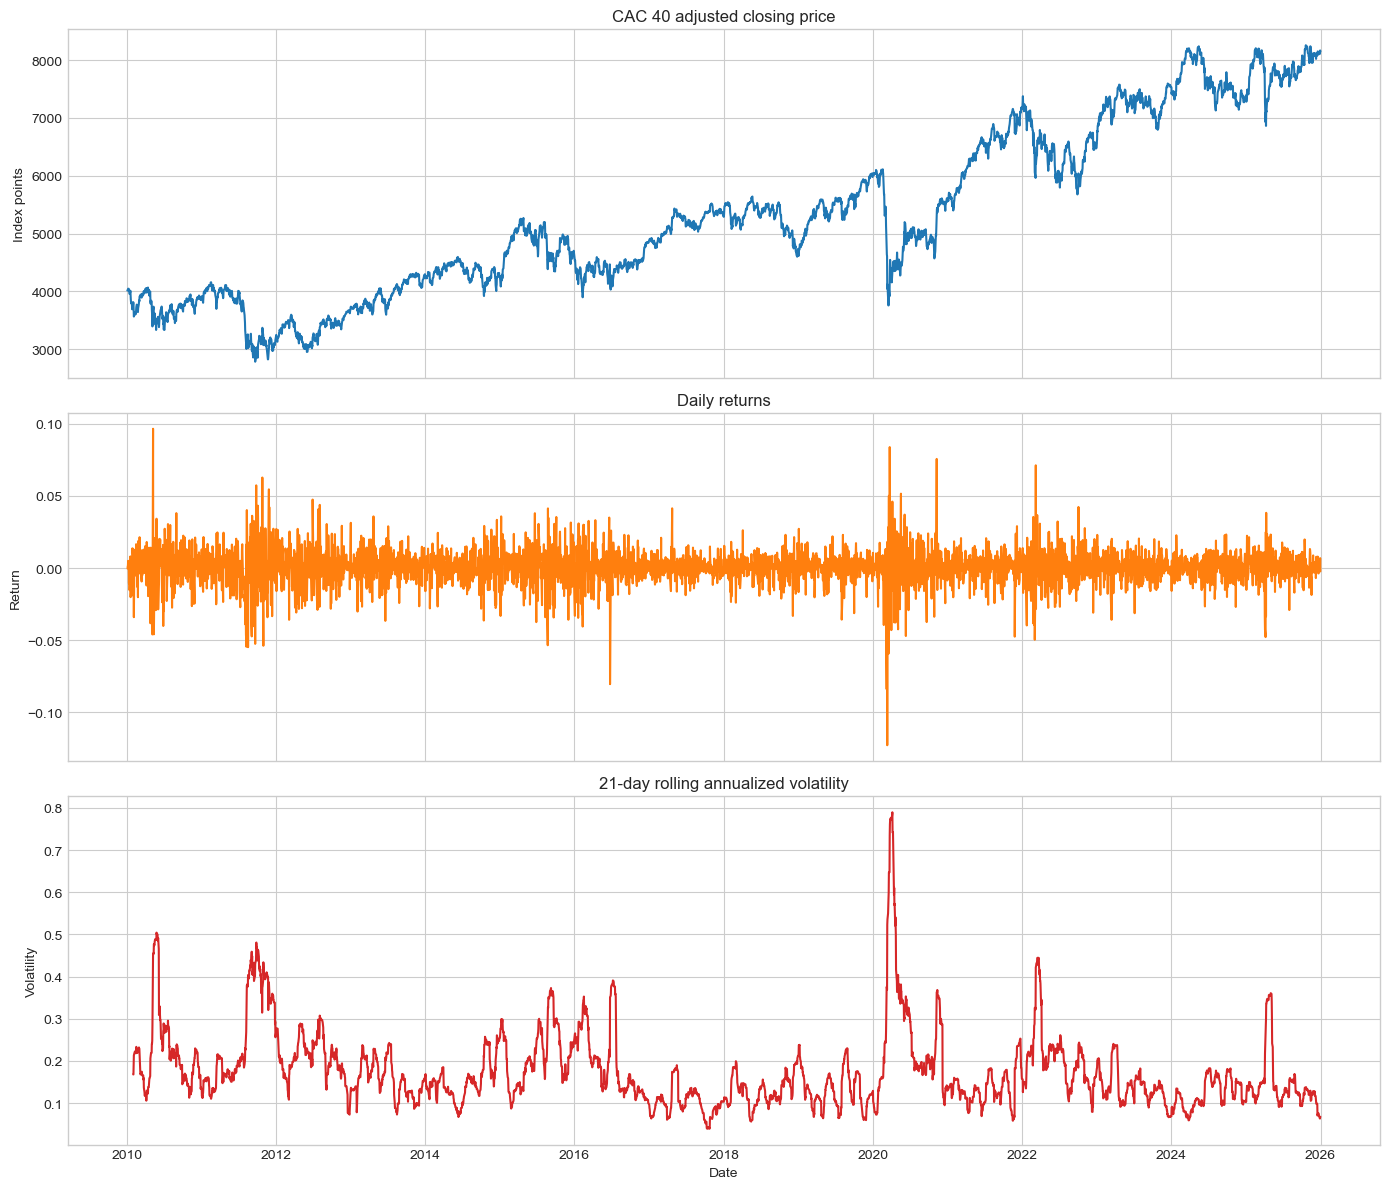

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df.index, df["close"], color="tab:blue")
axes[0].set_title("CAC 40 adjusted closing price")
axes[0].set_ylabel("Index points")

axes[1].plot(df.index, df["return_1d"], color="tab:orange")
axes[1].set_title("Daily returns")
axes[1].set_ylabel("Return")

axes[2].plot(df.index, df["volatility_21"], color="tab:red")
axes[2].set_title("21-day rolling annualized volatility")
axes[2].set_ylabel("Volatility")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

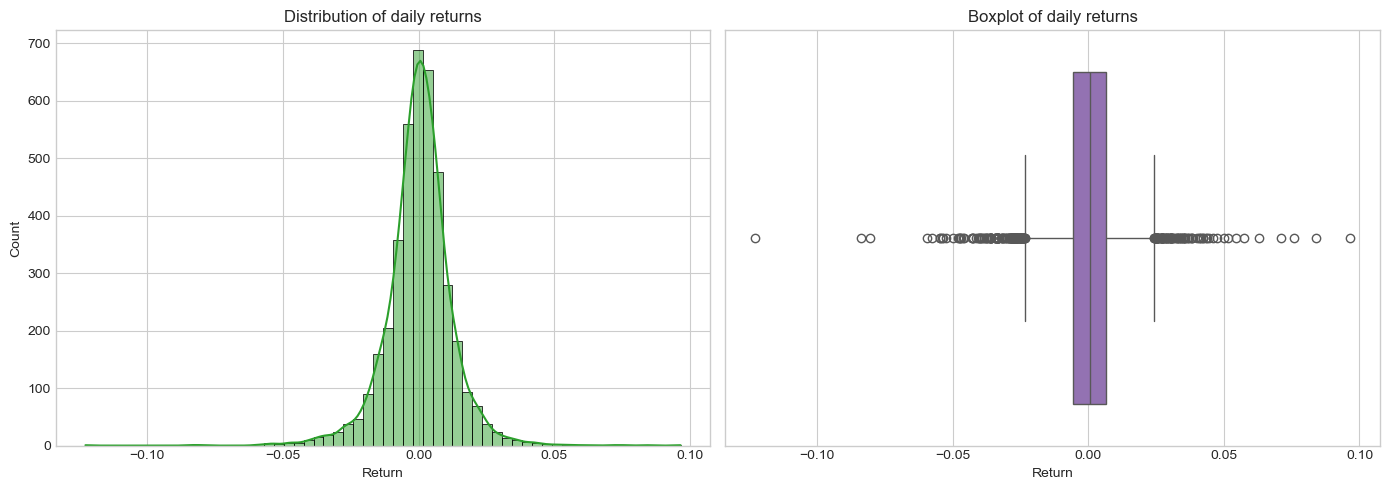

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["return_1d"].dropna(), bins=60, kde=True, ax=axes[0], color="tab:green")
axes[0].set_title("Distribution of daily returns")
axes[0].set_xlabel("Return")

sns.boxplot(x=df["return_1d"].dropna(), ax=axes[1], color="tab:purple")
axes[1].set_title("Boxplot of daily returns")
axes[1].set_xlabel("Return")

plt.tight_layout()
plt.show()

The return distribution is centered near zero and looks approximately bell-shaped in the middle but it also shows heavier tails and several extreme observations which suggests a deviation from perfect normality.

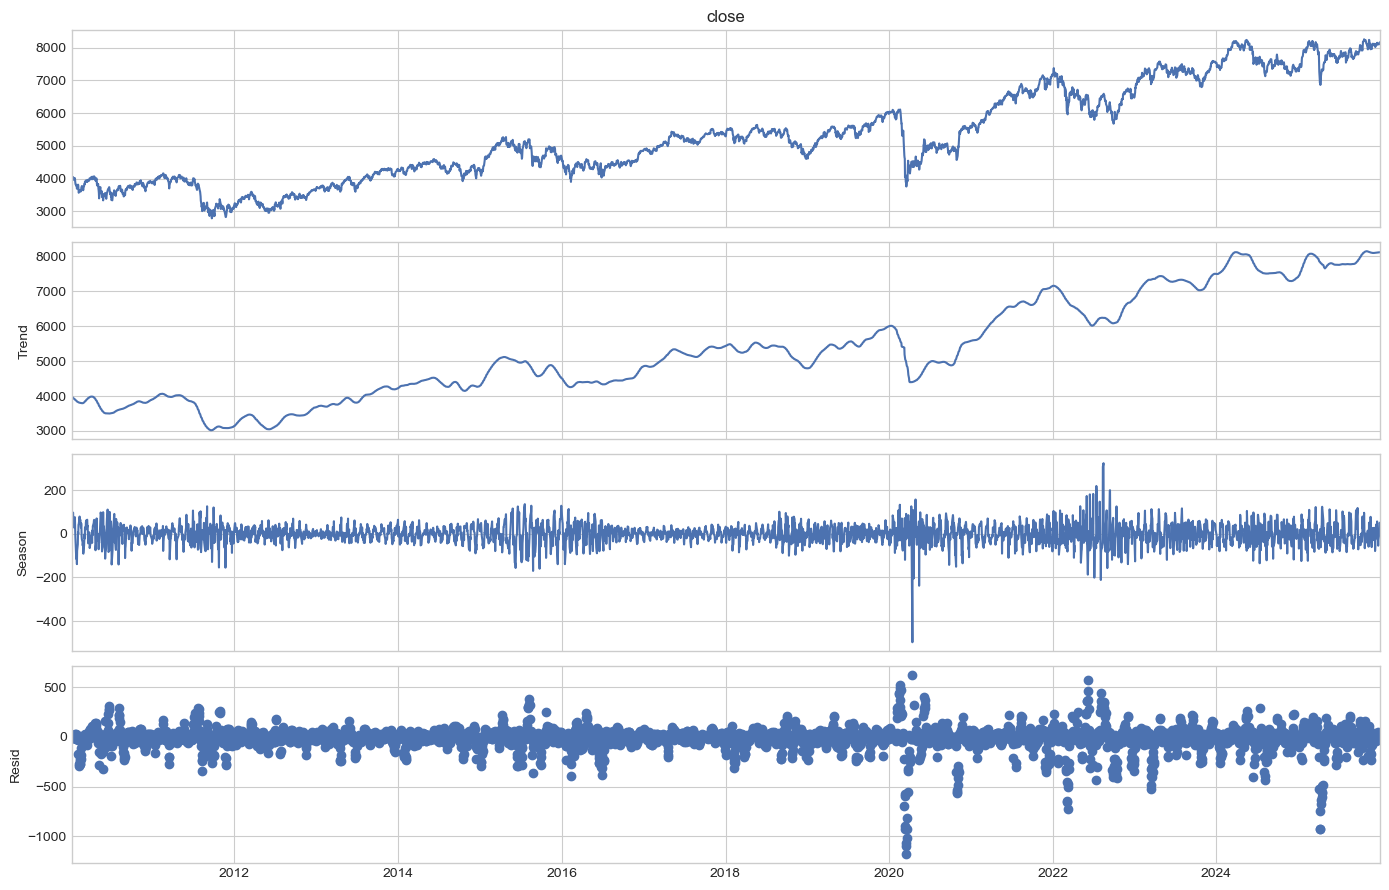

In [ ]:
stl = STL(df["close"], period=21, robust=True).fit()
stl_fig = stl.plot()
stl_fig.set_size_inches(14, 9)
plt.tight_layout()
plt.show()

The STL decomposition is mainly used here as a descriptive tool. For an equity index, the trend component is usually more important than any regular seasonal pattern. In this case, the decomposition mainly highlights the trend and the residual shocks, while the seasonal part remains limited.

,Statistic,p-value,1% threshold,5% threshold,10% threshold
ADF test on the first difference of log-prices,-23.4385,0.0,-3.432,-2.8622,-2.5671


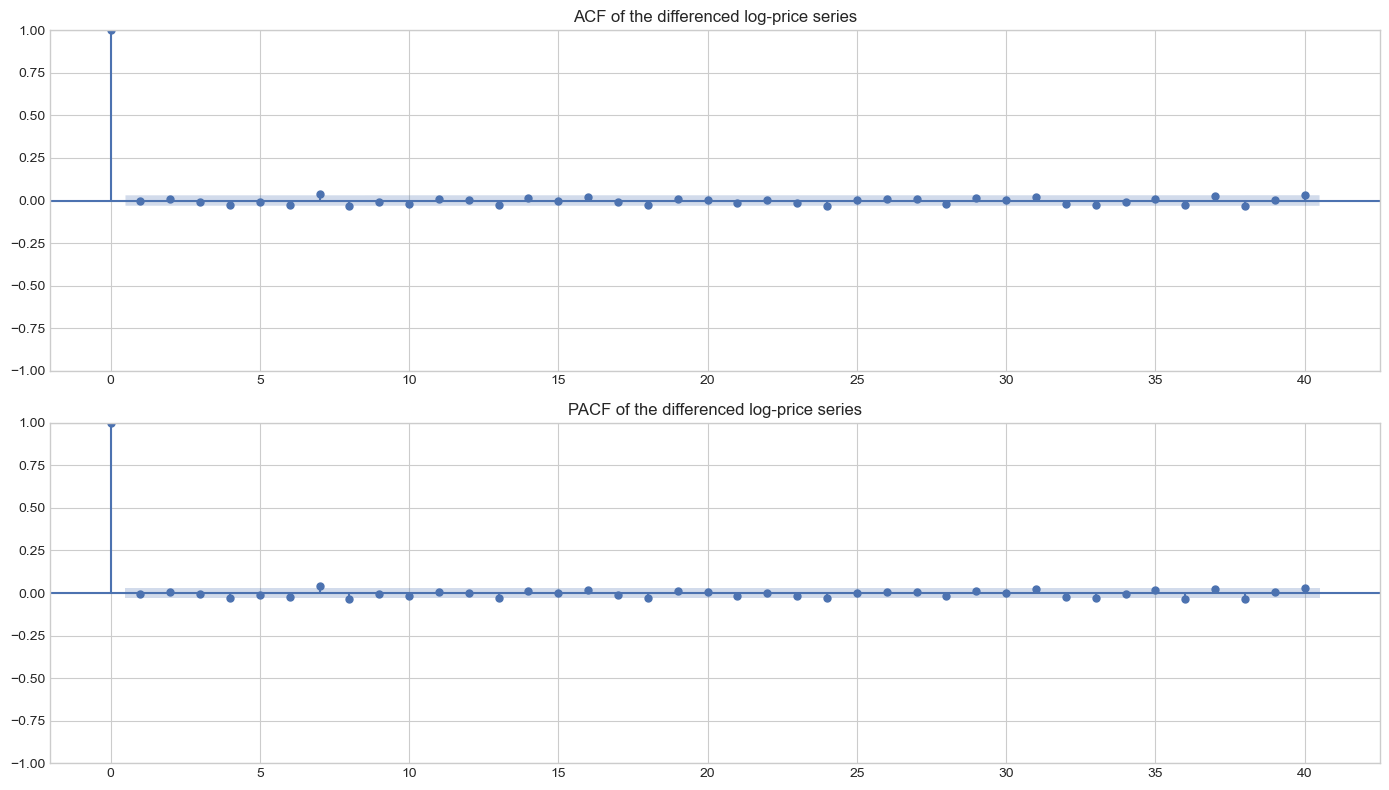

In [ ]:
stationary_series = df["log_close"].diff().dropna()
adf_stat, adf_pvalue, _, _, critical_values, _ = adfuller(stationary_series)

adf_table = pd.DataFrame(
    {
        "Statistic": [adf_stat],
        "p-value": [adf_pvalue],
        "1% threshold": [critical_values["1%"]],
        "5% threshold": [critical_values["5%"]],
        "10% threshold": [critical_values["10%"]],
    },
    index=["ADF test on the first difference of log-prices"],
)

display(adf_table.round(4))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(stationary_series, lags=40, ax=axes[0])
axes[0].set_title("ACF of the differenced log-price series")

plot_pacf(stationary_series, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF of the differenced log-price series")

plt.tight_layout()
plt.show()

The Augmented Dickey-Fuller test strongly rejects the null hypothesis of a unit root once the series is differenced in log-levels. This is consistent with the usual intuition in finance : the index level is not stationary whereas a transformed version of the series is more suitable for statistical modelling.

## 3. Feature engineering and supervised learning format

For the machine learning section, the time series is converted into a tabular supervised-learning problem. Each row corresponds to one prediction date and each feature is computed only with information available before that date.

The engineered predictors include:

- lagged prices
- lagged returns
- rolling means and rolling standard deviations
- momentum indicators
- cyclical encodings of calendar effects

In [ ]:
supervised = pd.DataFrame(index=df.index)

for lag in [1, 2, 3, 5, 10, 21]:
    supervised[f"lag_{lag}"] = df["close"].shift(lag)

supervised["return_1d"] = df["close"].pct_change().shift(1)
supervised["return_5d"] = df["close"].pct_change(5).shift(1)
supervised["volume_lag_1"] = df["volume"].shift(1)

supervised["rolling_mean_5"] = df["close"].shift(1).rolling(5).mean()
supervised["rolling_mean_10"] = df["close"].shift(1).rolling(10).mean()
supervised["rolling_mean_21"] = df["close"].shift(1).rolling(21).mean()

supervised["rolling_std_5"] = df["close"].shift(1).rolling(5).std()
supervised["rolling_std_10"] = df["close"].shift(1).rolling(10).std()
supervised["rolling_std_21"] = df["close"].shift(1).rolling(21).std()

supervised["momentum_5"] = df["close"].shift(1) / df["close"].shift(6) - 1
supervised["momentum_21"] = df["close"].shift(1) / df["close"].shift(22) - 1

supervised["day_of_week"] = df.index.dayofweek
supervised["month"] = df.index.month
supervised["dow_sin"] = np.sin(2 * np.pi * supervised["day_of_week"] / 5)
supervised["dow_cos"] = np.cos(2 * np.pi * supervised["day_of_week"] / 5)
supervised["month_sin"] = np.sin(2 * np.pi * supervised["month"] / 12)
supervised["month_cos"] = np.cos(2 * np.pi * supervised["month"] / 12)

supervised["target"] = df["close"]
supervised = supervised.dropna().copy()

feature_columns = [
    col for col in supervised.columns
    if col not in ["target", "day_of_week", "month"]
]

display(supervised.head())
print(f"Number of usable rows after feature engineering: {len(supervised)}")

,lag_1,lag_2,lag_3,lag_5,lag_10,lag_21,return_1d,return_5d,volume_lag_1,rolling_mean_5,rolling_mean_10,rolling_mean_21,rolling_std_5,rolling_std_10,rolling_std_21,momentum_5,momentum_21,day_of_week,month,dow_sin,dow_cos,month_sin,month_cos,target
date,,,,,,,,,,,,,,,,,,,,,,,,
2010-02-03,3812.129883,3762.010010,3739.459961,3759.800049,3928.949951,4012.909912,0.013323,0.001337,134752600.0,3752.437988,3796.296997,3907.846180,44.520884,67.003129,119.359864,0.001337,-0.050284,2,2,0.587785,-0.809017,0.866025,0.5,3793.469971
2010-02-04,3793.469971,3812.129883,3762.010010,3688.790039,3862.159912,4017.669922,-0.004895,0.008955,124554600.0,3759.171973,3782.748999,3897.396659,48.298880,48.282131,119.307592,0.008955,-0.054683,3,2,-0.587785,-0.809017,0.866025,0.5,3689.250000
2010-02-05,3689.250000,3793.469971,3812.129883,3739.459961,3820.780029,4024.800049,-0.027474,0.000125,175687000.0,3759.263965,3765.458008,3881.757615,48.131462,47.640626,124.179151,0.000125,-0.081744,4,2,-0.951057,0.309017,0.866025,0.5,3563.760010
2010-02-08,3563.760010,3689.250000,3793.469971,3762.010010,3781.850098,4045.139893,-0.034015,-0.046985,263299600.0,3724.123975,3739.756006,3859.803327,101.146001,75.602977,137.649693,-0.046985,-0.114550,0,2,0.000000,1.000000,0.866025,0.5,3607.270020
2010-02-09,3607.270020,3563.760010,3689.250000,3812.129883,3807.040039,4043.090088,0.012209,-0.041132,169862000.0,3693.175977,3722.297998,3838.952381,109.946187,84.442679,141.287330,-0.041132,-0.108246,1,2,0.951057,0.309017,0.866025,0.5,3612.760010


Number of usable rows after feature engineering: 4069


In [ ]:
split_idx = int(len(supervised) * (1 - TEST_SIZE))

train = supervised.iloc[:split_idx].copy()
test = supervised.iloc[split_idx:].copy()

X_train = train[feature_columns]
y_train = train["target"]
X_test = test[feature_columns]
y_test = test["target"]

print(f"Training set size: {len(train)} observations")
print(f"Test set size: {len(test)} observations")
print(f"First test date: {test.index.min().date()}")
print(f"Last test date: {test.index.max().date()}")

Training set size: 3255 observations
Test set size: 814 observations
First test date: 2022-10-25
Last test date: 2025-12-31


The train/test split strictly respects chronology. This is a key point in time-series forecasting because a random split would leak future information into the training set and would produce overly optimistic results.

## 4. Statistical modelling: baseline and SARIMAX

The first benchmark is a **naive persistence model**. In other words, the best guess for today's closing price is yesterday's closing price. This baseline is very simple, but it is often difficult to beat on market price levels.

The statistical model selected for the assignment is a **SARIMAX(1,1,1)**. To keep the evaluation realistic, the model is tested with **one-step-ahead rolling forecasts**: at each step, the next value is forecast and the observed test value is then added before moving to the following date.

In [ ]:
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
    }


results = {}
predictions = pd.DataFrame(index=y_test.index)
predictions["Actual"] = y_test

baseline_pred = test["lag_1"].rename("Naive baseline")
predictions["Naive baseline"] = baseline_pred
results["Naive baseline"] = compute_metrics(y_test, baseline_pred)

pd.DataFrame(results).T.round(3)

,RMSE,MAE,MAPE (%)
Naive baseline,66.451,49.689,0.666


In [ ]:
y_train_sarimax = pd.Series(y_train.to_numpy(), index=pd.RangeIndex(len(y_train)))
y_test_sarimax = y_test.copy()

sarimax_model = SARIMAX(
    y_train_sarimax,
    order=(1, 1, 1),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_result = sarimax_model.fit(disp=False)

sarimax_forecasts = []
next_idx = len(y_train_sarimax)

for observed_value in y_test_sarimax.to_numpy():
    next_forecast = float(sarimax_result.get_forecast(steps=1).predicted_mean.iloc[0])
    sarimax_forecasts.append(next_forecast)
    observed_series = pd.Series([observed_value], index=pd.RangeIndex(next_idx, next_idx + 1))
    sarimax_result = sarimax_result.append(observed_series, refit=False)
    next_idx += 1

sarimax_pred = pd.Series(sarimax_forecasts, index=y_test.index, name="SARIMAX(1,1,1)")
predictions["SARIMAX(1,1,1)"] = sarimax_pred
results["SARIMAX(1,1,1)"] = compute_metrics(y_test, sarimax_pred)

pd.DataFrame(results).T.sort_values("RMSE").round(3)

,RMSE,MAE,MAPE (%)
"SARIMAX(1,1,1)",66.420,49.790,0.667
Naive baseline,66.451,49.689,0.666


## 5. Classical machine learning models

The assignment explicitly asks for three model families:

1. a linear method
2. a bagging method
3. a boosting method

The following models are retained:

- **Ridge regression** for the linear benchmark
- **Random Forest** for bagging
- **Gradient Boosting** for boosting

This selection is standard and makes the comparison easy to interpret.

In [ ]:
models = {
    "Ridge": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=10.0)),
        ]
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        random_state=42,
    ),
}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    model_pred = pd.Series(model.predict(X_test), index=X_test.index, name=model_name)
    predictions[model_name] = model_pred
    results[model_name] = compute_metrics(y_test, model_pred)

comparison_ml = pd.DataFrame(results).T.sort_values("RMSE").round(3)
comparison_ml

,RMSE,MAE,MAPE (%)
"SARIMAX(1,1,1)",66.420,49.790,0.667
Naive baseline,66.451,49.689,0.666
Ridge,71.573,53.357,0.714
Random Forest,506.146,392.991,5.021
Gradient Boosting,551.981,441.303,5.652


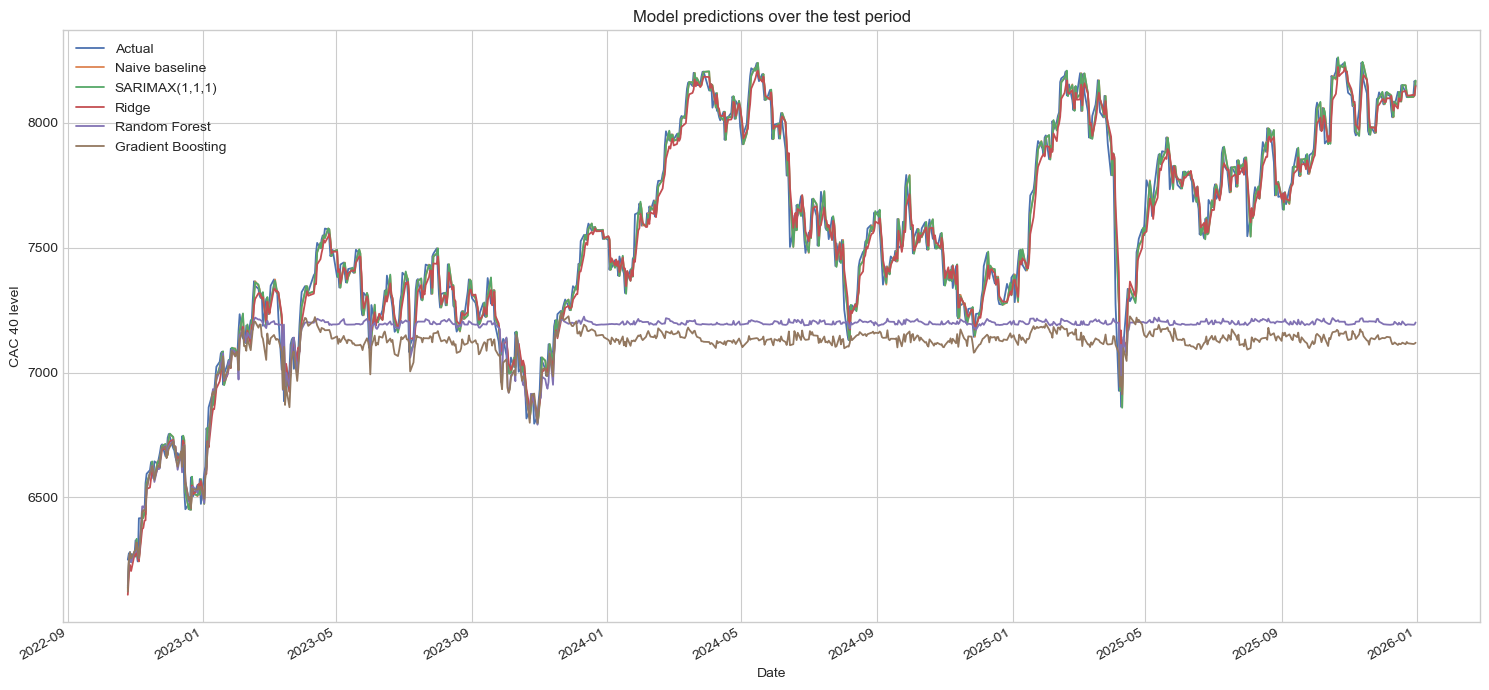

In [ ]:
fig, ax = plt.subplots(figsize=(15, 7))

plot_columns = [
    "Actual",
    "Naive baseline",
    "SARIMAX(1,1,1)",
    "Ridge",
    "Random Forest",
    "Gradient Boosting",
]

available_plot_columns = [col for col in plot_columns if col in predictions.columns]
predictions[available_plot_columns].plot(ax=ax, linewidth=1.3)

ax.set_title("Model predictions over the test period")
ax.set_ylabel("CAC 40 level")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

At this stage, the machine learning results already give a useful insight. Tree-based models often perform well when local nonlinearities matter, but they may struggle when they have to extrapolate a persistent trend beyond the range mostly seen during training. This is especially important for equity indices because level can drift upward over long periods.

## 6. Deep learning with an LSTM

The deep-learning section follows the requirements of the brief :

- scaling with `MinMaxScaler`
- reshaping the data into a 3D tensor
- using a validation set during training
- plotting the training and validation loss curves to monitor overfitting

In [ ]:
close_series = df["close"].copy()
split_test_date = test.index.min()

scaler = MinMaxScaler()
scaler.fit(close_series.loc[close_series.index < split_test_date].to_frame())
scaled_close = scaler.transform(close_series.to_frame())


def make_sequences(values, window):
    X, y = [], []
    for i in range(window, len(values)):
        X.append(values[i - window:i])
        y.append(values[i])
    return np.array(X), np.array(y)


X_all, y_all = make_sequences(scaled_close, LSTM_WINDOW)
sequence_index = close_series.index[LSTM_WINDOW:]

train_mask = sequence_index < split_test_date
test_mask = sequence_index >= split_test_date

X_train_lstm = X_all[train_mask]
y_train_lstm = y_all[train_mask]
X_test_lstm = X_all[test_mask]
y_test_lstm = y_all[test_mask]
test_index_lstm = sequence_index[test_mask]

val_size = max(30, int(len(X_train_lstm) * 0.15))
X_train_seq, X_val = X_train_lstm[:-val_size], X_train_lstm[-val_size:]
y_train_seq, y_val = y_train_lstm[:-val_size], y_train_lstm[-val_size:]

print("LSTM tensor shapes")
print("X_train:", X_train_seq.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test_lstm.shape)

LSTM tensor shapes
X_train: (2768, 21, 1)
X_val: (488, 21, 1)
X_test: (814, 21, 1)


In [ ]:
lstm_model = Sequential(
    [
        Input(shape=(LSTM_WINDOW, 1)),
        LSTM(64, return_sequences=True),
        Dropout(0.20),
        LSTM(32),
        Dropout(0.20),
        Dense(16, activation="relu"),
        Dense(1),
    ]
)

lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0,
)

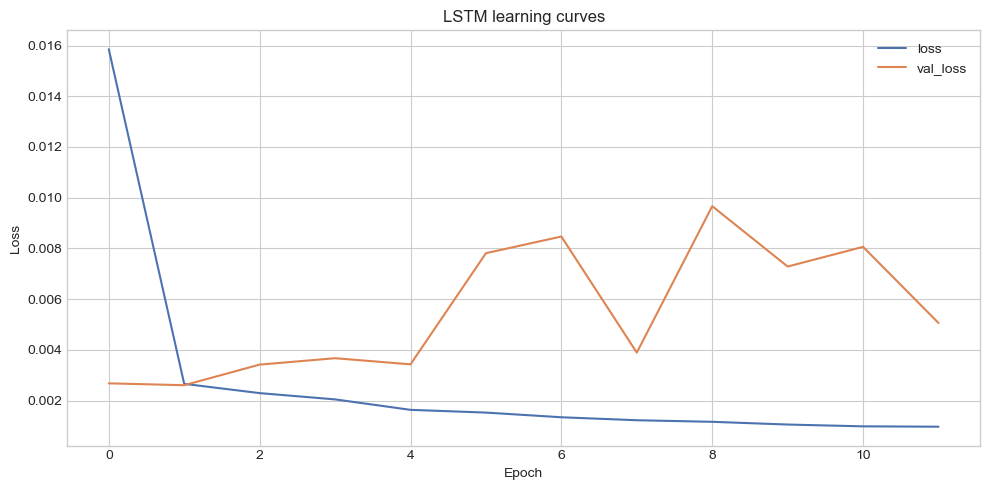

In [ ]:
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(figsize=(10, 5))
history_df[["loss", "val_loss"]].plot(ax=ax)
ax.set_title("LSTM learning curves")
ax.set_ylabel("Loss")
ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

In [ ]:
lstm_scaled_pred = lstm_model.predict(X_test_lstm, verbose=0)

lstm_pred = scaler.inverse_transform(lstm_scaled_pred).ravel()

lstm_pred_series = pd.Series(lstm_pred, index=test_index_lstm, name="LSTM")
predictions["LSTM"] = lstm_pred_series

common_index = y_test.index.intersection(lstm_pred_series.index)
results["LSTM"] = compute_metrics(y_test.loc[common_index], lstm_pred_series.loc[common_index])

comparison = pd.DataFrame(results).T.sort_values("RMSE").round(3)
comparison

,RMSE,MAE,MAPE (%)
"SARIMAX(1,1,1)",66.420,49.790,0.667
Naive baseline,66.451,49.689,0.666
Ridge,71.573,53.357,0.714
LSTM,414.430,385.090,5.057
Random Forest,506.146,392.991,5.021
Gradient Boosting,551.981,441.303,5.652


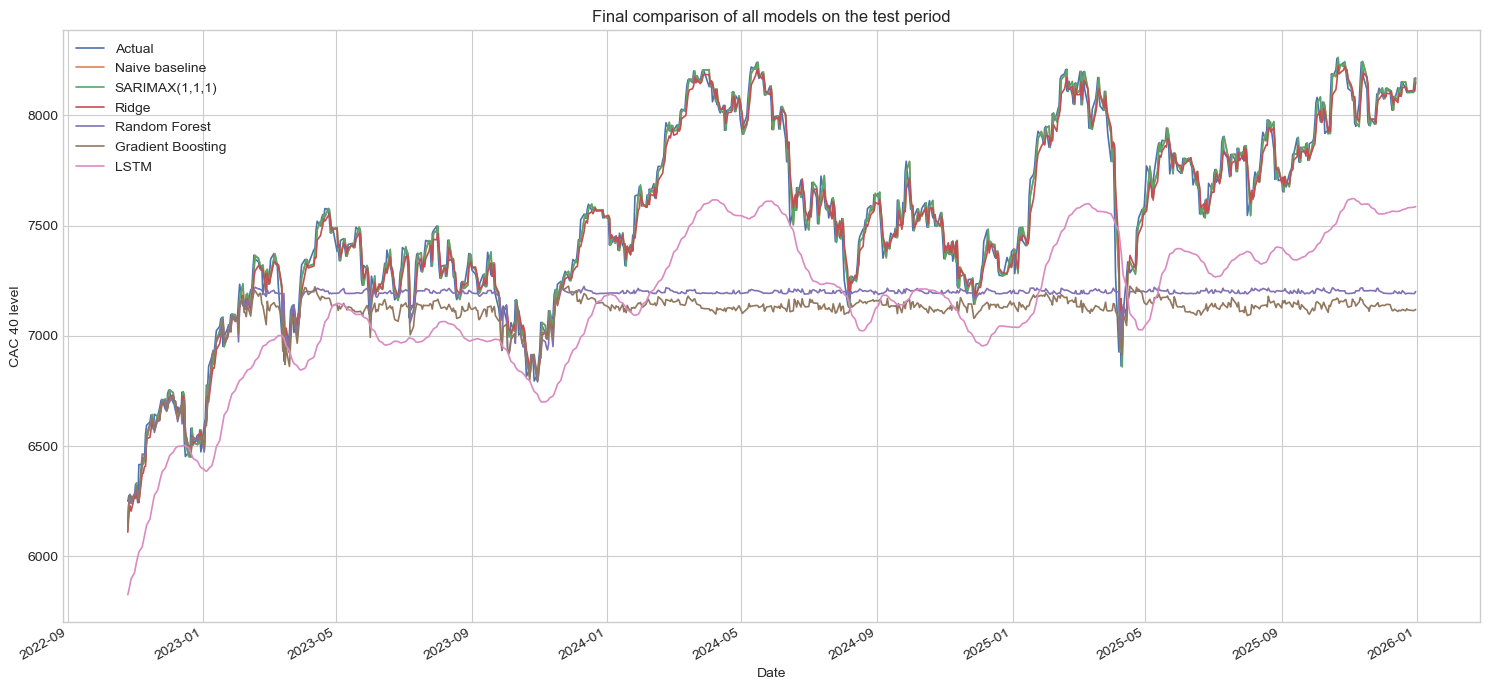

In [ ]:
fig, ax = plt.subplots(figsize=(15, 7))

final_plot_columns = [
    "Actual",
    "Naive baseline",
    "SARIMAX(1,1,1)",
    "Ridge",
    "Random Forest",
    "Gradient Boosting",
    "LSTM",
]

available_final_plot_columns = [col for col in final_plot_columns if col in predictions.columns]
predictions[available_final_plot_columns].plot(ax=ax, linewidth=1.2)

ax.set_title("Final comparison of all models on the test period")
ax.set_ylabel("CAC 40 level")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

## 7. Final discussion

The comparison table can now be used to answer the main practical questions raised in the assignment:

- Which model performs best on the unseen test period?
- Does the extra complexity of machine learning or deep learning pay off?
- Do tree-based methods struggle with trend extrapolation?
- Is the gain large enough to justify a more expensive modelling pipeline?

In [ ]:
comparison.to_csv(DATA_DIR / "model_comparison.csv")
predictions.to_csv(DATA_DIR / "test_predictions.csv")

best_model = comparison.index[0]
best_rmse = comparison.iloc[0]["RMSE"]

print(f"Best model according to RMSE: {best_model} (RMSE = {best_rmse:.3f})")

if "Random Forest" in comparison.index and "Ridge" in comparison.index:
    if comparison.loc["Random Forest", "RMSE"] > comparison.loc["Ridge", "RMSE"]:
        print(
            "Random Forest underperforms the linear benchmark, which suggests that tree-based splits "
            "do not extrapolate the index trend particularly well over this test period."
        )
    else:
        print(
            "Random Forest outperforms the linear benchmark, which indicates that nonlinear effects "
            "seem informative in this forecasting task."
        )

if "LSTM" in comparison.index and "Ridge" in comparison.index:
    if comparison.loc["LSTM", "RMSE"] < comparison.loc["Ridge", "RMSE"]:
        print(
            "The LSTM improves on the linear model, so the additional modelling complexity appears justified here."
        )
    else:
        print(
            "The LSTM is more costly to train and does not generate a clear improvement over simpler benchmarks."
        )

Best model according to RMSE: SARIMAX(1,1,1) (RMSE = 66.420)
Random Forest underperforms the linear benchmark, which suggests that tree-based splits do not extrapolate the index trend particularly well over this test period.
The LSTM is more costly to train and does not generate a clear improvement over simpler benchmarks.


### Conclusion

The main lesson of this study is that higher model complexity does not automatically lead to better predictive accuracy for financial time series. On the CAC 40, a very simple benchmark remains hard to beat, and more elaborate methods only bring limited improvements, if any.

From a practical point of view, this result matters. A model that is slightly more accurate but much harder to train, monitor and explain may not be the best choice in practice. In that sense, this project is not only about forecasting accuracy but also about the trade-off between complexity, robustness and usefulness.